# MDP e Value Iteration

## Setup

### Imports

In [3]:
from typing import Any
import numpy as np
import matplotlib.pyplot as plt

### Classe `GridWorldMDP`

In [ ]:
class GridWorldMDP:
    def __init__(
            self,
            shape=(3,4),
            goal=(0,3),
            traps=[(1,3)],
            terminals=[(0,3), (1,3)],
            obstacles=[(1,1)],
            goal_reward=10,
            trap_reward=-10
        ) -> None:
        self.shape = shape
        self.goal = goal                # Posição da grid
        self.traps = traps              # Posição da grid
        self.terminals = terminals      # Posição da grid
        self.obstacles = obstacles      # Posição da grid
        self.goal_reward = goal_reward  # Recompensa
        self.trap_reward = trap_reward  # Recompensa

    def get_reward(self, state) -> int:
        if state == self.goal:
            return self.goal_reward
        elif state in self.traps:
            return self.trap_reward
        else:
            return 0

    def is_valid_state(self, state) -> bool:
        i, j = state
        if i < 0 or i >= self.shape[0] or j < 0 or j >= self.shape[1]:
            return False
        if state in self.obstacles:
            return False
        return True

    def next_state(self, state, action) -> tuple[Any, Any]:
        # Ações:
        #   0 = Up      ↑
        #   1 = Down    ↓
        #   2 = Left    ←
        #   3 = Right   →
        moves = {
            0: (-1, 0),
            1: (1, 0),
            2: (0, -1),
            3: (0, 1)
        }

        di, dj = moves[action]
        next_s = (state[0] + di, state[1] + dj)

        if not self.is_valid_state(next_s):
            return state
        return next_s

    def state_to_index(self, state) -> Any:
        i, j = state
        return i * self.shape[1] + j

    def index_to_state(self, index) -> tuple[Any, Any]:
        i = index // self.shape[1]
        j = index % self.shape[1]
        return (i, j)

    def get_all_states(self) -> range:
      return range(0, self.shape[0]*self.shape[1])

    def get_all_actions(self) -> range:
      return range(0,4)

    def build_mdp(self):
        n_states = self.shape[0] * self.shape[1]
        n_actions = 4  # Cima, Baixo, Esquerda, Direita

        # P[a][s, s']
        P = np.zeros((n_actions, n_states, n_states))

        # R[s, a]
        R = np.zeros((n_states, n_actions))

        for i in range(self.shape[0]):
            for j in range(self.shape[1]):
                state = (i, j)
                s_idx = self.state_to_index(state)

                if state in self.obstacles:
                    continue

                for action in range(n_actions):

                    if state in self.terminals:
                        P[action, s_idx, s_idx] = 1.0
                        R[s_idx, action] = 0
                        continue

                    next_s = self.next_state(state, action)
                    next_idx = self.state_to_index(next_s)

                    P[action, s_idx, next_idx] = 1.0  # P é sempre 1 pois o nosso MDP é determinístico
                    R[s_idx, action] = self.get_reward(next_s)
        return P, R

### Função para Visualizar o Grid World

In [ ]:
def plot_gridworld(env, policy=None, values=None) -> None:
    rows, cols = env.shape[0], env.shape[1]
    arrow_dirs = {
      0: (-1, 0),  # Up     ↑
      1: (1, 0),   # Down   ↓
      2: (0, -1),  # Left   ←
      3: (0, 1),   # Right  →
    }
    fig, ax = plt.subplots(figsize=(cols, rows))

    for x in range(rows + 1):
        ax.axhline(x, lw=1, color="black")
    for y in range(cols + 1):
        ax.axvline(y, lw=1, color="black")

    for i in range(rows):
        for j in range(cols):
            y = rows - i - 1
            state = (i, j)

            if state in env.obstacles:
                color = "black"
            else:
                color = "white"

            ax.add_patch(plt.Rectangle((j, y), 1, 1, color=color))  # type: ignore (Pylance)

            if state == env.goal or state in env.traps:
                reward = env.get_reward(state)
                ax.text(j + 0.5, y + 0.3, f"{reward}",
                        ha='center', va='center', fontsize=14, color='black')

            if state in env.terminals:
                ax.text(
                    j + 0.5,
                    y + 0.6,
                    "Term",
                    ha="center",
                    va="center",
                    fontsize=14,
                    color="black"
                )
            state_index = env.state_to_index(state)

            if values is not None and state not in env.terminals and state not in env.obstacles:
                val = values[state_index]
                ax.text(
                    j + 0.5,
                    y + 0.1,
                    f"{val:.2f}",
                    ha="center",
                    va="center",
                    fontsize=8,
                    color="blue"
                )

            if policy is not None and state not in env.terminals and state not in env.obstacles:
                action = policy[state_index]
                dx, dy = arrow_dirs[action]
                ax.arrow(
                    j + 0.5, y + 0.5,
                    dy * 0.3, -dx * 0.3,
                    head_width=0.2, head_length=0.2,
                    fc='black', ec='black'
                )

    ax.set_xlim(0, cols)
    ax.set_ylim(0, rows)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title("")

    plt.show()

Visualizar o Grid World

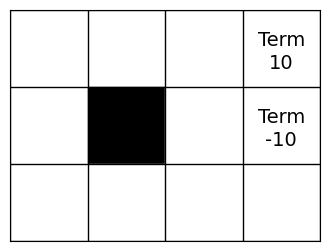

In [7]:
env = GridWorldMDP()
plot_gridworld(env)

## Exercício Prático

### 1. Implementar o Algoritmo _Value Iteration_

In [9]:
gamma = 0.9
epsilon = 0.01
P, R = env.build_mdp()

In [8]:
def value_iteration(states, actions, P, R, gamma, epsilon):
    V = {s : 0 for s in states}
    policy = {}

    while True:
        delta = 0

        for s in states:
            v = V[s]
            V[s] = max((sum(P[a,s,s_next] * (R[s,a] + gamma * V[s_next]) for s_next in states)) for a in actions)
            delta = max(delta, abs(v - V[s]))

        if delta < epsilon:
            break

    for s in states:
        policy[s] = max(actions, key = lambda a: sum(P[a,s,s_next] * (R[s,a] + gamma * V[s_next]) for s_next in states))
    return policy, V

Executar o Algoritmo

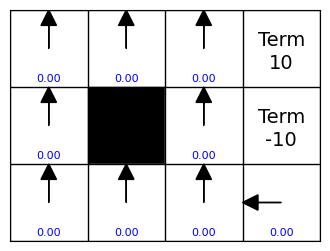

In [14]:
policy, value_function = value_iteration(env.get_all_states(), env.get_all_actions(), P, R, gamma, epsilon)
plot_gridworld(env, policy=policy, values=value_function)

## 2. Executar o _Value Iteraction_ em um Novo Ambiente

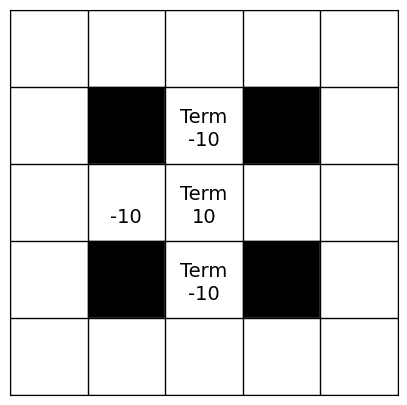

In [12]:
new_env = GridWorldMDP(
    shape=(5,5),
    goal=(2,2),
    traps=[(1,2), (2,1), (3,2)],
    terminals=[(2,2), (1,2), (3,2)],
    obstacles=[(1,1), (3,1), (1,3), (3,3)]
)

plot_gridworld(new_env)

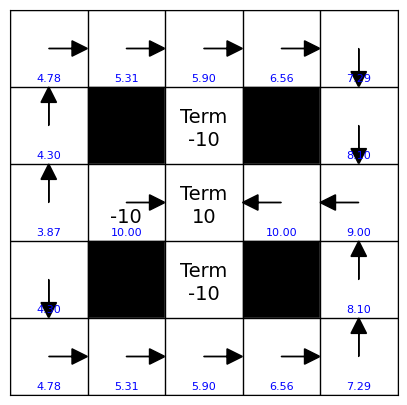

In [13]:
gamma = 0.9
epsilon = 0.01
P, R = new_env.build_mdp()
policy, value_function = value_iteration(new_env.get_all_states(), new_env.get_all_actions(), P, R, gamma, epsilon)

plot_gridworld(new_env, policy=policy, values=value_function)

#### Responder

1. Qual a política gerada para esse ambiente se mudarmos o fator de desconto ($γ$) para 0.1?

2. Observe o código do algoritmo na função `value_iteration()` e faça as alterações necessárias para que você possa responder à seguinte pergunta:
    - Com $γ = 0.9$, quantas iterações levam para o algoritmo convergir? Como os valores de $V$ para cada estado se alteram até a convergência?

3. Como que o valor do fator de desconto ($γ$) afeta o comportamento do algoritmo?